<a href="https://colab.research.google.com/github/Makande340/A01-data-wrangling/blob/main/notebook(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Mofeoluwa Akande

**Date:** 9/2/26

In [ ]:
#Q1.1

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

url = "/airbnb_hw.csv"
df = pd.read_csv(url)

print("df.shape:")
print(df.shape, '\n')

#listing available for information about types and columns
#removing commas and storing the value for Prices as a numeric were the main choices I made to clean Prices.

df['Price'] = df['Price'].str.replace(',', '', regex=False)
df['Price'] = df['Price'].astype(int)
df.info()



df.shape:
(30478, 13) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Host Id                     30478 non-null  int64  
 1   Host Since                  30475 non-null  object 
 2   Name                        30478 non-null  object 
 3   Neighbourhood               30478 non-null  object 
 4   Property Type               30475 non-null  object 
 5   Review Scores Rating (bin)  22155 non-null  float64
 6   Room Type                   30478 non-null  object 
 7   Zipcode                     30344 non-null  float64
 8   Beds                        30393 non-null  float64
 9   Number of Records           30478 non-null  int64  
 10  Number Of Reviews           30478 non-null  int64  
 11  Price                       30478 non-null  int64  
 12  Review Scores Rating        22155 non-null  float64
dtypes: floa

In [ ]:
#Q1.2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


url = "/mn_police_use_of_force.csv"
df = pd.read_csv(url)


var = 'subject_injury'
print(df[var].unique(), '\n')
print(df[var].value_counts(dropna=False), '\n')

print('Proportion of missing values:', df[var].isnull().mean())

pd.crosstab(df['force_type'], df['subject_injury'].isnull())
ct = pd.crosstab(df['force_type'], df['subject_injury'].isnull())
#calc to find percentage that is missing
ct['pct_missing'] = ct[True] / (ct[True] + ct[False]) * 100
ct

#main trend that is shown highlights pct missing for more common force_types and higher percentages being present for more niche and highly-server force types



[nan 'No' 'Yes'] 

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64 

Proportion of missing values: 0.7619342359767892


subject_injury,False,True,pct_missing
force_type,,,
Baton,2,2,50.000000
Bodily Force,2379,7051,74.772004
Chemical Irritant,172,1421,89.202762
Firearm,2,0,0.000000
Gun Point Display,77,27,25.961538
Improvised Weapon,74,74,50.000000
Less Lethal,0,87,100.000000
Less Lethal Projectile,3,0,0.000000
Maximal Restraint Technique,0,170,100.000000


--2026-09-05 21:08:16--  https://sharkattackfile.net/spreadsheets/GSAF5.xls
Resolving sharkattackfile.net (sharkattackfile.net)... 192.252.150.253
Connecting to sharkattackfile.net (sharkattackfile.net)|192.252.150.253|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5541376 (5.3M) [application/vnd.ms-excel]
Saving to: ‘GSAF5.xls.19’

GSAF5.xls.19        100%[===================>]   5.28M  23.3MB/s    in 0.2s    

2026-09-05 21:08:16 (23.3 MB/s) - ‘GSAF5.xls.19’ saved [5541376/5541376]



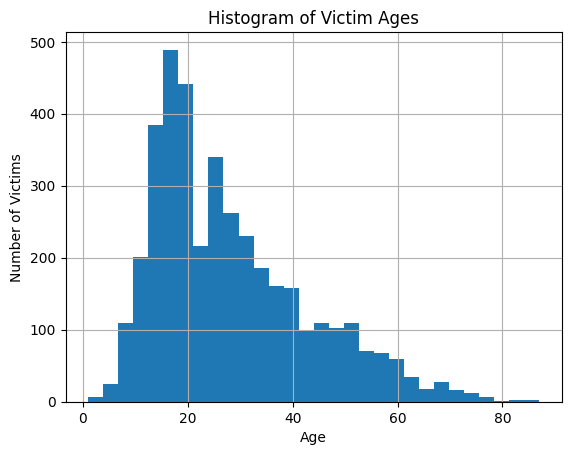

0.8747511866482928
73.94969790642124


In [ ]:
# Q2.1

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

!wget https://sharkattackfile.net/spreadsheets/GSAF5.xls

df = pd.read_excel("GSAF5.xls")


# Q2.2 - Drop unnecessary columns

df = df.drop(columns=[
    'pdf',
    'href formula',
    'href',
    'Case Number',
    'Case Number.1',
    'original order',
    'Unnamed: 21',
    'Unnamed: 22'
])

# Q2.3 - Cleaned variable by changing Year from float to integer. Also looked at range of values within year column and found that year 0 is just a representation for years with a specific data not specified

df['Year'] = df['Year'].astype('Int64')
df['Year'].min(), df['Year'].max()
df[df['Year'] == 0]

# Filter and print rows from 1940 down

df_1940_2026 = df[
    (df['Year'] >= 1940) &
    (df['Year'] <= 2026)
].sort_values('Year')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

#over time the amount of fatal shark attacks were limited from 1940 to 2026. Earlier on there was a mix majority of incidents ending up being fatal, and that number began to dwindle as the years progressed. Attacks themself seemingly remained constant though.

df_1940_2026

#Q2.4:

# Clean Age variable
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Histogram of victim ages
df['Age'].hist(bins=30)

plt.xlabel('Age')
plt.ylabel('Number of Victims')
plt.title('Histogram of Victim Ages')
plt.show()

#Q2.5:

sex_clean = df['Sex'].str.strip().str.upper()
male_proportion = (sex_clean == 'M').sum() / sex_clean.isin(['M', 'F']).sum()
print(male_proportion)
#After filtering out Sex to be strictly M and F, I found that about 87% of the proportion were men

#Q2.6
#cleaning type variable
df['Type'] = df['Type'].str.strip().str.lower()

#recoding values
df['Type'] = df['Type'].replace({
    'unprovoked': 'Unprovoked',
    'provoked': 'Provoked'
})
#recoded other values as unknown
df.loc[~df['Type'].isin(['Unprovoked', 'Provoked']), 'Type'] = 'Unknown'
df['Type'].value_counts(dropna=False)

#after making only three values within type variable, I was able to then take the amount of values that showed for Unprovoked and calculate the percentage compared to the other two value.
unprovoked_percentage = df['Type'].value_counts(normalize=True)['Unprovoked'] * 100
print(unprovoked_percentage)

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:**
- **AI tool and model used:**

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]